#Regression Analysis and Model Comparison - Hotazel Steam

# Made by Anthony Quach

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

#how to get rid of scientific notation
pd.options.display.float_format = '{:.2f}'.format

HS_data = pd.read_csv('AICPA_regressionAnalysisData.csv')

display(HS_data)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


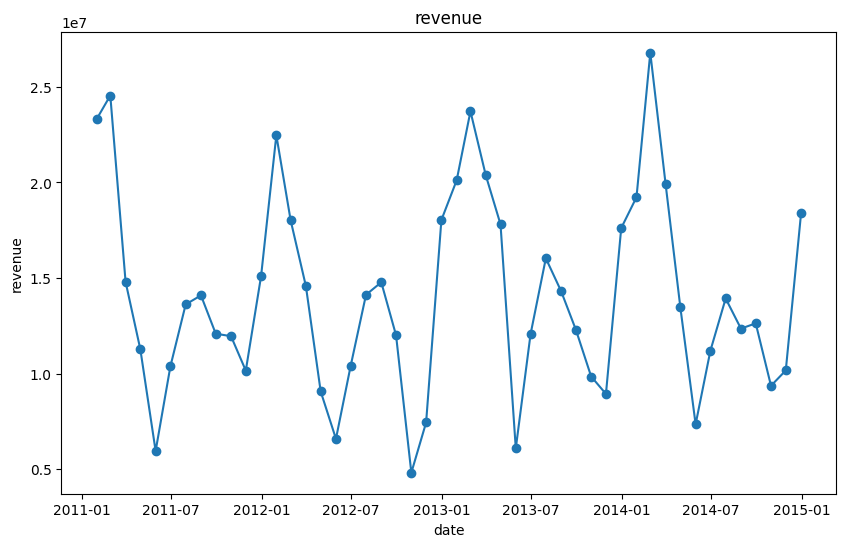

In [ ]:
#Step 0: make sure the date is a date type by converting the column to a date type
HS_data['date'] = pd.to_datetime(HS_data['date'])

#Start with visualizing the data
# use plt.figure() to create the canvas
# use plt.title(), plt.xlabel(), plt.ylabel() to label the visualization
# finally, use plt.plot to actually plot the data

plt.figure(figsize=(10,6))

plt.title('revenue')

plt.xlabel('date')
plt.ylabel('revenue')

#plt.plot(datapoints on the x axis, datapoints on the y axis, any visualization stuff like colours)
plt.plot(HS_data['date'], HS_data['revenue'], marker='o')

In [ ]:
# find correlation between variables
HS_data.loc[:,['revenue','production','coolDD']].corr()


,revenue,production,coolDD
revenue,1.00,0.63,-0.17
production,0.63,1.00,0.51
coolDD,-0.17,0.51,1.00


In [ ]:
HS_data

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


In [ ]:
# prepare the datasets for training and testing


dt4training = HS_data.loc[HS_data['type']=='dt4training']
dt4testing = HS_data.loc[HS_data['type']=='dt4testing']



In [ ]:

# we prepare the independent and depenedent variables FOR TRAINING
#dependent
y = dt4training.loc[:,'revenue']
#independent
x = dt4training.loc[:,'production']

#add the constant to independant variable (production)
x = sm.add_constant(x)


model1 = sm.OLS(y,x).fit()
#finding paramaters of model, const is x int and production is the slope
model1.params

,0
const,4897663.26
production,18.99


In [ ]:
model1.summary() #to find regression results

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                revenue   R-squared:                       0.397
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     22.35
Date:                Sat, 11 Jul 2026   Prob (F-statistic):           3.86e-05
Time:                        03:53:27   Log-Likelihood:                -598.32
No. Observations:                  36   AIC:                             1201.
Df Residuals:                      34   BIC:                             1204.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.898e+06   2.01e+06      2.431      0.020    8.03e+05    8.99e+06
production    18.9920      4.017      4.728      0.000      10.828      27.156
==============================================================================
Omnibus:                        5.412   Durbin-Watson:                   0.444
Prob(Omnibus):                  0.067   Jarque-Bera (JB):                2.625
Skew:                           0.392   Prob(JB):                        0.269
Kurtosis:                       1.934   Cond. No.                     1.47e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.47e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
# to test model using predict funtion
x_test = dt4testing.loc[:,'production']

#add the constant to the testing side
x_test = sm.add_constant(x_test)


model1.predict(x_test)

,0
36,16414428.69
37,18460401.82
38,20197640.55
39,12035930.72
40,10202060.55
41,14727936.65
42,19131656.04
43,17497582.00
44,18223533.25
45,12717212.73


In [ ]:
# new df with preidcted revenue and actual revenue

model1_assessment = dt4testing.copy()
model1_assessment['predicted_revenue'] = model1.predict(x_test)

# calculation of absolute pct error

model1_assessment['abs_pct_error'] = abs((
    model1_assessment['revenue']-model1_assessment['predicted_revenue'])
/model1_assessment['revenue'])

display(model1_assessment)


,type,date,revenue,production,coolDD,heatDD,predicted_revenue,abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,16414428.69,0.15
37,dt4testing,2014-02-28,26792280,714128,0,938,18460401.82,0.31
38,dt4testing,2014-03-31,19935840,805600,0,866,20197640.55,0.01
39,dt4testing,2014-04-30,13468000,375856,0,412,12035930.72,0.11
40,dt4testing,2014-05-31,7344128,279296,49,88,10202060.55,0.39
41,dt4testing,2014-06-30,11196216,517600,230,0,14727936.65,0.32
42,dt4testing,2014-07-31,13929472,749472,380,0,19131656.04,0.37
43,dt4testing,2014-08-31,12352176,663432,322,0,17497582.00,0.42
44,dt4testing,2014-09-30,12628944,701656,178,14,18223533.25,0.44
45,dt4testing,2014-10-31,9361000,411728,24,166,12717212.73,0.36


In [ ]:
model1_assessment['abs_pct_error'].mean() #to find mean MAPE score

np.float64(0.2542315606071484)

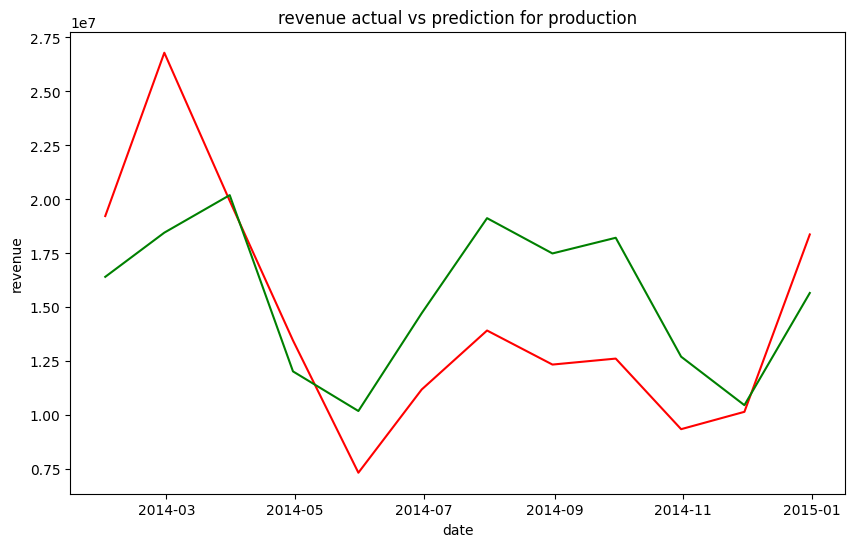

In [ ]:
#visualize the models performance using the assessment table
plt.figure(figsize=(10,6))

plt.title('revenue actual vs prediction for production')
plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(model1_assessment['date'],model1_assessment['revenue'], color='red')
plt.plot(model1_assessment['date'],model1_assessment['predicted_revenue'], color='green')

In [ ]:
dt4training2 = HS_data.loc[HS_data['type']=='dt4training']
dt4testing2 = HS_data.loc[HS_data['type']=='dt4testing']

In [ ]:
# repeat all steps for coolDD (new independent var)
y2 = dt4training2.loc[:,'revenue']

x2 = dt4training2.loc[:,'coolDD']


x2 = sm.add_constant(x2)


model2 = sm.OLS(y2,x2).fit()

model2.params

,0
const,14341632.04
coolDD,-4113.94


In [ ]:
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                revenue   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                 -0.012
Method:                 Least Squares   F-statistic:                    0.5883
Date:                Sat, 11 Jul 2026   Prob (F-statistic):              0.448
Time:                        03:53:28   Log-Likelihood:                -607.10
No. Observations:                  36   AIC:                             1218.
Df Residuals:                      34   BIC:                             1221.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.434e+07   1.08e+06     13.275      0.000    1.21e+07    1.65e+07
coolDD     -4113.9355   5363.430     -0.767      0.448    -1.5e+04    6785.866
==============================================================================
Omnibus:                        0.850   Durbin-Watson:                   0.964
Prob(Omnibus):                  0.654   Jarque-Bera (JB):                0.822
Skew:                           0.142   Prob(JB):                        0.663
Kurtosis:                       2.317   Cond. No.                         249.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
x_test2 = dt4testing2.loc[:,'coolDD']

x_test2 = sm.add_constant(x_test2)



model2.predict(x_test2)

,0
36,14341632.04
37,14341632.04
38,14341632.04
39,14341632.04
40,14140049.20
41,13395426.88
42,12778336.56
43,13016944.82
44,13609351.53
45,14242897.59


In [ ]:
model2_assessment = dt4testing2.copy()
model2_assessment['predicted_revenue'] = model2.predict(x_test2)



model2_assessment['abs_pct_error'] = abs((
    model2_assessment['revenue']-model2_assessment['predicted_revenue'])
/model2_assessment['revenue'])

display(model2_assessment)

,type,date,revenue,production,coolDD,heatDD,predicted_revenue,abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,14341632.04,0.25
37,dt4testing,2014-02-28,26792280,714128,0,938,14341632.04,0.46
38,dt4testing,2014-03-31,19935840,805600,0,866,14341632.04,0.28
39,dt4testing,2014-04-30,13468000,375856,0,412,14341632.04,0.06
40,dt4testing,2014-05-31,7344128,279296,49,88,14140049.20,0.93
41,dt4testing,2014-06-30,11196216,517600,230,0,13395426.88,0.20
42,dt4testing,2014-07-31,13929472,749472,380,0,12778336.56,0.08
43,dt4testing,2014-08-31,12352176,663432,322,0,13016944.82,0.05
44,dt4testing,2014-09-30,12628944,701656,178,14,13609351.53,0.08
45,dt4testing,2014-10-31,9361000,411728,24,166,14242897.59,0.52


In [ ]:
model2_assessment['abs_pct_error'].mean()

np.float64(0.2960295810593141)

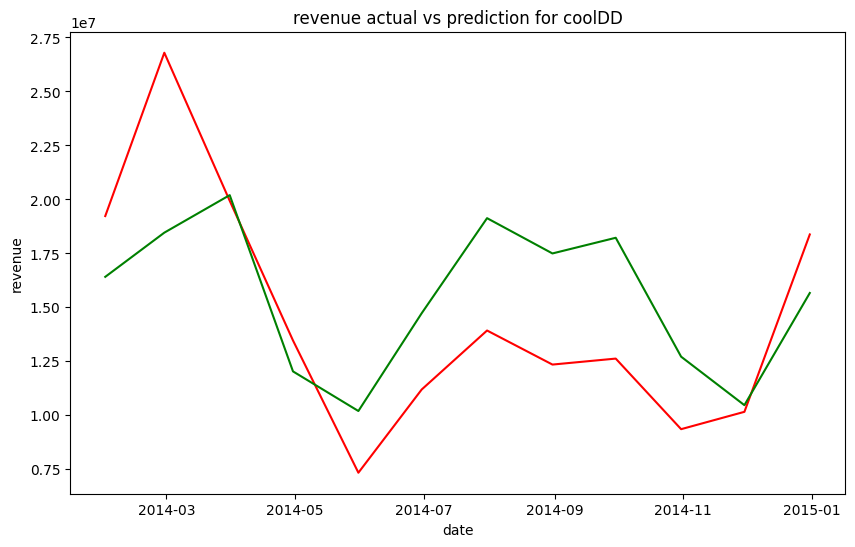

In [ ]:
plt.figure(figsize=(10,6))

plt.title('revenue actual vs prediction for coolDD')
plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(model1_assessment['date'],model1_assessment['revenue'], color='red')
plt.plot(model1_assessment['date'],model1_assessment['predicted_revenue'], color='green')

To: Hotazel Steam
From: Anthony Quach, Analyst, Quantfolio Solutions
Date: 2026-07-10
Re: Model 1 using production better for forecasting revenue

BLUF. After comparing 2 regression models using production and coolDD, we have determined that the model using production to be more accurate with a MAPE score of 25.4% vs. 29.6%. As such, we recommendd using the first model as a basis for forecasting future revenue.

Scope. We framed the business problem as a data problem,: train two linear regression models with the dependant variable revenue using the independent variables of production and coolDD to determing the best variable to forecast future revenue. The timespan of the data was 2011-2014, with the comparison to reality being 2014-2015.

Methodology. Data: We analyzed data using Python (pandas,matplotlib.pyplot, statsmodels.api) a CSV dataset containing revenue, production, and coolDD information from 2011-2015. We created 2 separate models with respective dependent/independent variables, trained them, found the MAPE score by calculating the absolute percent error of revenue and predicted revenue.

Key findings.
1. Model 1 forecasts more accurately out-of-sample. It had a MAPE score of 25.4% vs. 29.6% for model 2. This suggests that production tracks the actual seasonal revenue swings while coolDD stays near-flat and misses them.

2. Both models had a low Adjusted R-squared values of 0.379 and -0.012 respectively. This suggests that the variance in revenue cannot be explained by either production or coolDD, and that coolDD may be worse than no predictor at all.

 Obs: [figure + % + $]. Interp: [meaning]. Confidence: [level]. 2. [Next, by importance.]

Recommendations.
1. Do not use coolDD when modelling for revenue forecasting as a negative adjusted r-squaredd value suggests that the variance in revenue was not caused by coolDD.

2. Adopt production as a temporary revenue predictor as a .379 adjusted r-squared and a MAPE score of 25.4% suggesst that while not accurate, there are some correlation between revenue and production. We suggest that Hotazel Steam explore other models to find a more suitable variable for more accurate forecasts.